# ***GRADIENT BOOSTING: ADABOOST Y XGBOOST***

En este notebook se aplican modelos de **Gradient Boosting** sobre el dataset preprocesado de diabetes. El objetivo es evaluar modelos de boosting para la predicción de la variable objetivo `readmitted`, usando siempre la misma separación de datos y las mismas métricas principales.

El análisis se centra en dos modelos principales: **AdaBoost** y **XGBoost**. Además, se añade un modelo de **Gradient Boosting complementario** para tener una referencia adicional dentro de la misma familia de métodos, aunque la comparación principal se realiza sobre AdaBoost y XGBoost.

La metodología seguida es la siguiente: primero se realiza la separación **train/test**, después se entrenan modelos base, posteriormente se aplica **GridSearchCV** para ajustar hiperparámetros, se analiza la **importancia de características** y finalmente se comparan todos los resultados en una tabla final.

Para que los resultados sean comparables con los de otros modelos del proyecto, se utiliza validación cruzada con **5 folds** y se evalúan las métricas **Accuracy**, **Precision Macro**, **Recall Macro** y **F1-Score Macro**. La métrica principal para decidir el mejor modelo es **F1 macro**, porque en este problema no interesa únicamente acertar la clase mayoritaria, sino equilibrar el rendimiento entre las distintas clases de `readmitted`.


In [ ]:
# LIBRERÍAS NECESARIAS

from pathlib import Path
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import (train_test_split,StratifiedKFold,GridSearchCV,cross_val_score)
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from sklearn.base import clone


warnings.filterwarnings("ignore")

In [ ]:
SEED = 42
np.random.seed(SEED)

In [5]:
# Carga del dataset preprocesado
# Se prueban varias rutas para que el notebook funcione tanto en local como en la estructura del proyecto.

ruta_dataset = "../data/diabetes_preprocesado.csv"

if ruta_dataset is None:
    raise FileNotFoundError("No se ha encontrado el archivo diabetes_preprocesado.csv. Revisa la ruta del dataset.")

df = pd.read_csv(ruta_dataset)

print(f"Dataset cargado desde: {ruta_dataset}")
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")

df.head()

Dataset cargado desde: ../data/diabetes_preprocesado.csv
Dimensiones del dataset: 98053 filas y 46 columnas


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,0.765698,1,1,1,1,7,-0.302638,0.492774,...,0,3,0,0,0,0,0,1,1,1
1,64410,86047875,0.192559,1,2,1,1,7,-0.841183,0.492774,...,0,0,0,0,0,0,0,0,1,0
2,500364,82442376,0.765698,0,3,1,1,7,-0.841183,0.492774,...,0,3,0,0,0,0,0,1,1,0
3,16680,42519267,0.765698,0,4,1,1,7,-1.600220,0.492774,...,0,2,0,0,0,0,0,1,1,0
4,35754,82637451,0.765698,0,5,2,1,2,-0.302638,0.492774,...,0,2,0,0,0,0,0,0,1,1


## 1- Separación train-test

En primer lugar, se separan las variables predictoras de la variable objetivo `readmitted`. Todas las columnas excepto `readmitted` se utilizan como entrada del modelo, mientras que `readmitted` queda como variable a predecir.

Después se divide el dataset en dos partes: un conjunto de entrenamiento y un conjunto de prueba. El entrenamiento se usa para ajustar los modelos y la prueba se reserva para evaluar el rendimiento final sobre datos no utilizados durante el entrenamiento.

Se utiliza `stratify=y` en la división train-test. Esto es importante porque mantiene una proporción similar de clases en ambos conjuntos y evita que una clase quede sobrerrepresentada o infrarrepresentada en train o en test.


In [ ]:
# 1. Definición de variables predictoras y variable objetivo
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

# 2. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# 3. Visualización de la distribución de clases
resumen_split = pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "Filas": [X_train.shape[0], X_test.shape[0]],
    "Columnas predictoras": [X_train.shape[1], X_test.shape[1]]
})

distribucion_clases = pd.concat([
    y_train.value_counts(normalize=True).sort_index().rename("Train"),
    y_test.value_counts(normalize=True).sort_index().rename("Test")
], axis=1).round(4)

distribucion_clases.index.name = "Clase readmitted"

display(resumen_split)
display(distribucion_clases)

,Conjunto,Filas,Columnas predictoras
0,Train,78442,45
1,Test,19611,45


,Train,Test
Clase readmitted,,
0,0.5338,0.5338
1,0.3534,0.3534
2,0.1129,0.1128


La separación realizada deja **78.442 filas** para entrenamiento y **19.611 filas** para prueba. En ambos casos se mantienen **45 columnas predictoras**, ya que la columna `readmitted` se ha separado como variable objetivo.

La tabla de distribución de clases confirma que la estratificación ha funcionado correctamente. La clase `0` representa el **53,38%** tanto en train como en test, la clase `1` representa el **35,34%** en ambos conjuntos y la clase `2` representa el **11,29%** en train y el **11,28%** en test. Por tanto, la proporción de clases queda prácticamente idéntica en las dos particiones.

Este punto es relevante porque el dataset no está balanceado. La clase mayoritaria supera la mitad de los ejemplos, mientras que la clase menos frecuente se queda alrededor del 11%. Por eso, una métrica como la accuracy puede dar una visión incompleta del rendimiento, ya que un modelo podría acertar muchos casos de la clase mayoritaria y seguir funcionando mal en las clases menos representadas.

Por este motivo, en el resto del notebook se da mucha importancia al **F1 macro**, la **precisión macro** y el **recall macro**. Estas métricas permiten evaluar el comportamiento medio entre clases y no solo el porcentaje total de aciertos.


In [ ]:
# Funciones auxiliares para mantener el mismo formato de tablas en todo el notebook

cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


def metricas_test(modelo, X_test, y_test):
    # Calcula las métricas solicitadas sobre el conjunto de test.
    y_pred = modelo.predict(X_test)
    return {
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision Macro": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall Macro": round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "F1-Score Macro": round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4)
    }


def evaluar_modelo_base(nombre, modelo, X_train, X_test, y_train, y_test):
    # Entrena el modelo, calcula validación cruzada con F1 macro y evalúa en test.
    inicio = time.time()
    cv_scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv_5,
        scoring="f1_macro",
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)
    metricas = metricas_test(modelo, X_test, y_test)
    tiempo = round(time.time() - inicio, 2)

    fila = {
        "Modelo": nombre,
        "CV F1 Macro": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        **metricas,
        "Tiempo (s)": tiempo
    }

    return pd.DataFrame([fila]).set_index("Modelo")


def resumen_busqueda_grid(nombre_modelo, grid, param_cols, X_train, X_test, y_train, y_test, top_n=10):
    # Convierte los resultados de GridSearchCV en una tabla con el top de configuraciones.
    cv_results = pd.DataFrame(grid.cv_results_)

    columnas_cv = [f"param_{col}" for col in param_cols]
    resultados = cv_results[
        columnas_cv + ["mean_test_score", "std_test_score", "rank_test_score", "params"]
    ].copy()

    resultados = resultados.rename(columns={
        **{f"param_{col}": col for col in param_cols},
        "mean_test_score": "CV F1 Macro",
        "std_test_score": "CV Std",
        "rank_test_score": "Ranking",
        "params": "__params__"
    })

    resultados = resultados.sort_values(
        by=["Ranking", "CV F1 Macro"],
        ascending=[True, False]
    ).reset_index(drop=True)

    top_resultados = resultados.head(top_n).copy()
    parametros_top = top_resultados["__params__"].tolist()

    metricas_top = []
    for params in parametros_top:
        # Se usan los parámetros originales de GridSearchCV para conservar tipos correctos.
        modelo_tmp = clone(grid.estimator).set_params(**params)
        modelo_tmp.fit(X_train, y_train)
        metricas_top.append(metricas_test(modelo_tmp, X_test, y_test))

    top_resultados = top_resultados.drop(columns=["__params__"])
    metricas_top = pd.DataFrame(metricas_top)
    top_resultados = pd.concat([top_resultados.reset_index(drop=True), metricas_top], axis=1)

    mejor_modelo = grid.best_estimator_
    mejor_metricas = metricas_test(mejor_modelo, X_test, y_test)

    mejor_fila = {
        **grid.best_params_,
        "CV F1 Macro": round(grid.best_score_, 4),
        "CV Std": round(
            cv_results.loc[grid.best_index_, "std_test_score"],
            4
        ),
        "Ranking": 1,
        **mejor_metricas
    }

    df_mejor = pd.DataFrame([mejor_fila], index=[f"Mejor {nombre_modelo}"])
    df_top = top_resultados.copy()
    df_top.index = [f"Top {i}" for i in range(1, len(df_top) + 1)]

    columnas_ordenadas = param_cols + [
        "CV F1 Macro",
        "CV Std",
        "Ranking",
        "Test Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1-Score Macro"
    ]

    df_resumen = pd.concat([df_top[columnas_ordenadas], df_mejor[columnas_ordenadas]])
    return df_resumen, mejor_modelo

## 2- AdaBoost con configuración base

El primer modelo entrenado es **AdaBoost Base**. Esta versión sirve como punto de partida antes de realizar la búsqueda de hiperparámetros.

En esta configuración se utiliza un árbol de decisión muy sencillo como estimador base, con `max_depth=1`. Además, se fija `n_estimators=50` y `learning_rate=0.10`. Por tanto, no es todavía el modelo optimizado, sino una referencia inicial para comprobar qué rendimiento se obtiene con una configuración controlada y sencilla.

Como en el resto del notebook, se calcula validación cruzada con **5 folds** usando `F1 macro` y después se evalúa el modelo en el conjunto de test mediante `Accuracy`, `Precision Macro`, `Recall Macro` y `F1-Score Macro`.


In [ ]:
# 1. Configuración y entrenamiento del modelo AdaBoost base
ada_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=SEED
    ),
    n_estimators=50,
    learning_rate=0.10,
    random_state=SEED
)

# 2. Validación cruzada y métricas de test
df_ada_base = evaluar_modelo_base(
    "AdaBoost Base",
    ada_base,
    X_train,
    X_test,
    y_train,
    y_test
)

display(df_ada_base)

,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Tiempo (s)
Modelo,,,,,,,
AdaBoost Base,0.3296,0.0031,0.5599,0.3502,0.372,0.3287,15.81


En primer lugar, el modelo **AdaBoost Base** obtiene un `CV F1 Macro` de **0.3296** con una desviación estándar de **0.0031**. Esto indica que, durante la validación cruzada, el rendimiento medio del modelo es bastante bajo, aunque estable entre particiones.

En el conjunto de test, la accuracy es de **0.5599**. A primera vista puede parecer un resultado aceptable porque supera el 50%, pero no debe interpretarse de forma aislada. Como se ha visto en la separación train-test, la clase mayoritaria representa aproximadamente el 53% de los datos, por lo que una accuracy cercana a 0.56 no garantiza que el modelo esté aprendiendo bien las clases minoritarias.

Las métricas macro muestran mejor esta limitación. La `Precision Macro` es de **0.3502**, el `Recall Macro` es de **0.3720** y el `F1-Score Macro` es de **0.3287**. Estos valores muestran que el modelo base todavía tiene dificultades para equilibrar precisión y recall entre las distintas clases de `readmitted`.

El valor de recall es especialmente importante porque mide la capacidad del modelo para detectar correctamente los casos reales de cada clase. En este caso, un recall macro de **0.3720** indica que el modelo todavía deja sin identificar una parte considerable de los ejemplos de algunas clases.

También se observa que el `F1-Score Macro` en test (**0.3287**) es muy parecido al `CV F1 Macro` obtenido en validación cruzada (**0.3296**). Esto sugiere que el modelo no está teniendo un comportamiento extraño entre validación y test, sino que su rendimiento limitado es consistente.

En resumen, AdaBoost Base sirve como referencia inicial, pero los resultados muestran que esta configuración sencilla no es suficiente para resolver bien el problema. Por eso tiene sentido continuar con una búsqueda de hiperparámetros que permita aumentar la complejidad del modelo y comprobar si se consigue una mejora real.


## 3- AdaBoost: Grid Search

Después de entrenar el modelo base, se realiza una búsqueda de hiperparámetros para **AdaBoost** mediante `GridSearchCV`.

El grid definido evalúa **4 hiperparámetros** con **4 valores cada uno**, lo que genera **256 combinaciones** diferentes. Como se utiliza validación cruzada con **5 folds**, el proceso implica **1.280 entrenamientos** en total.

Los hiperparámetros ajustados son `n_estimators`, `learning_rate`, `estimator__max_depth` y `estimator__min_samples_leaf`. La selección de la mejor configuración se realiza con `scoring="f1_macro"`, manteniendo el mismo criterio de comparación que en el resto del notebook.


In [ ]:
# 1. Definición del param_grid de AdaBoost
param_grid_ada = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.10, 0.50],
    "estimator__max_depth": [1, 2, 3, 4],
    "estimator__min_samples_leaf": [1, 2, 5, 10]
}

combinaciones_ada = np.prod([len(valores) for valores in param_grid_ada.values()])
entrenamientos_ada = combinaciones_ada * cv_5.get_n_splits()

print(f"Combinaciones AdaBoost: {combinaciones_ada}")
print(f"Entrenamientos con cv=5: {entrenamientos_ada}")

# 2. Configuración del GridSearchCV
ada_estimator = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=SEED),
    random_state=SEED
)

grid_ada = GridSearchCV(
    estimator=ada_estimator,
    param_grid=param_grid_ada,
    cv=cv_5,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)

# 3. Ejecución del GridSearchCV
inicio = time.time()
grid_ada.fit(X_train, y_train)
tiempo_ada = round(time.time() - inicio, 2)

print(f"Tiempo total GridSearchCV AdaBoost: {tiempo_ada} segundos")
print("Mejores parámetros AdaBoost:")
print(grid_ada.best_params_)
print(f"Mejor CV F1 Macro AdaBoost: {grid_ada.best_score_:.4f}")

# 4. Tabla con el top 10 y la mejor configuración
param_cols_ada = [
    "n_estimators",
    "learning_rate",
    "estimator__max_depth",
    "estimator__min_samples_leaf"
]

df_ada_grid, best_ada = resumen_busqueda_grid(
    "AdaBoost",
    grid_ada,
    param_cols_ada,
    X_train,
    X_test,
    y_train,
    y_test,
    top_n=10
)

display(df_ada_grid)

Combinaciones AdaBoost: 256
Entrenamientos con cv=5: 1280
Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Tiempo total GridSearchCV AdaBoost: 10297.11 segundos
Mejores parámetros AdaBoost:
{'estimator__max_depth': 4, 'estimator__min_samples_leaf': 5, 'learning_rate': 0.5, 'n_estimators': 200}
Mejor CV F1 Macro AdaBoost: 0.4138


,n_estimators,learning_rate,estimator__max_depth,estimator__min_samples_leaf,CV F1 Macro,CV Std,Ranking,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
Top 1,200,0.5,4,5,0.413764,0.005208,1,0.5941,0.5580,0.4294,0.4158
Top 2,200,0.5,4,2,0.413741,0.002447,2,0.5927,0.5410,0.4272,0.4120
Top 3,200,0.5,4,1,0.413591,0.002058,3,0.5927,0.5406,0.4275,0.4119
Top 4,200,0.5,4,10,0.413529,0.002119,4,0.5936,0.5496,0.4279,0.4119
Top 5,150,0.5,4,10,0.413154,0.002328,5,0.5922,0.5423,0.4260,0.4096
Top 6,150,0.5,4,1,0.411949,0.003991,6,0.5926,0.5342,0.4263,0.4098
Top 7,150,0.5,4,5,0.411903,0.005085,7,0.5926,0.5568,0.4271,0.4123
Top 8,150,0.5,4,2,0.411779,0.004776,8,0.5927,0.5448,0.4272,0.4121
Top 9,100,0.5,4,10,0.411717,0.002306,9,0.5929,0.5586,0.4268,0.4106
Top 10,100,0.5,4,1,0.410809,0.003881,10,0.5918,0.5432,0.4247,0.4077


La búsqueda de hiperparámetros de **AdaBoost** tarda **10.297,11 segundos** y evalúa las **256 combinaciones** previstas con **5 folds**, es decir, **1.280 entrenamientos**. Esto confirma que el ajuste realizado es bastante más costoso que el modelo base, pero también más completo.

La mejor configuración encontrada utiliza **200 estimadores**, `learning_rate=0.5`, `estimator__max_depth=4` y `estimator__min_samples_leaf=5`. Con esta configuración, el mejor `CV F1 Macro` es **0.4138** y el `F1-Score Macro` en test es **0.4158**.

La mejora respecto a **AdaBoost Base** es clara. El `F1-Score Macro` pasa de **0.3287** a **0.4158**, la accuracy sube de **0.5599** a **0.5941**, la precisión macro pasa de **0.3502** a **0.5580** y el recall macro aumenta de **0.3720** a **0.4294**. Por tanto, el ajuste de hiperparámetros mejora todas las métricas principales.

También es importante observar que las mejores configuraciones son muy parecidas entre sí. En el top 10, todas utilizan `learning_rate=0.5` y `estimator__max_depth=4`. Esto indica que, dentro del grid probado, AdaBoost obtiene sus mejores resultados cuando los árboles base son más profundos que el árbol inicial de profundidad 1 y cuando la tasa de aprendizaje es más alta que la usada en el modelo base.

El número de estimadores también influye. Las primeras posiciones se concentran principalmente en **200** y **150** estimadores, mientras que las configuraciones con **100** estimadores aparecen más abajo dentro del top 10. Aun así, las diferencias entre las primeras configuraciones son pequeñas: el `CV F1 Macro` del Top 1 es **0.413764** y el del Top 4 es **0.413529**, prácticamente el mismo valor.

En test, el mejor modelo de AdaBoost obtiene una accuracy de **0.5941**, una precisión macro de **0.5580**, un recall macro de **0.4294** y un F1 macro de **0.4158**. La precisión mejora bastante respecto al modelo base, pero el recall sigue siendo moderado, lo que indica que el modelo todavía no detecta todas las clases con la misma eficacia.

En conjunto, el Grid Search demuestra que AdaBoost mejora mucho al ajustar sus hiperparámetros, especialmente al permitir árboles base más complejos y una tasa de aprendizaje mayor. Sin embargo, aunque el rendimiento mejora, el F1 macro sigue estando alrededor de 0.416, por lo que el problema continúa siendo difícil y no queda resuelto completamente con AdaBoost.


### Nota técnica: recuperación de resultados de AdaBoost

La búsqueda completa de AdaBoost es la parte más costosa del notebook, ya que en la ejecución mostrada tarda más de **3 horas**. Por ese motivo, se incluye una celda de recuperación con los resultados reales ya obtenidos.

Esta celda no modifica la metodología del experimento. Su función es evitar repetir el `GridSearchCV` completo si el kernel se reinicia y se pierden las variables `df_ada_grid` o `best_ada`. De esta forma, el notebook puede seguir mostrando la comparación final y la importancia de características sin volver a esperar varias horas.


In [9]:
# ============================================================
# RECUPERACIÓN DE RESULTADOS DE ADABOOST SI LA VARIABLE NO EXISTE
# ============================================================
# Esta celda evita tener que volver a ejecutar el GridSearchCV de AdaBoost porque tarda 3 horas con CPU
# Ya se ejecutó una vez, entoces guardamos el Top 10 y se muestra si no hay ya unos valores.

import pandas as pd

if "df_ada_grid" not in globals():

    print("df_ada_grid no estaba definida. Se reconstruye con los resultados ya obtenidos de AdaBoost.")

    datos_ada_recuperados = [
        {
            "Modelo": "Top 1",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 5,
            "CV F1 Macro": 0.413764,
            "CV Std": 0.005208,
            "Ranking": 1,
            "Test Accuracy": 0.5941,
            "Precision Macro": 0.5580,
            "Recall Macro": 0.4294,
            "F1-Score Macro": 0.4158
        },
        {
            "Modelo": "Top 2",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 2,
            "CV F1 Macro": 0.413741,
            "CV Std": 0.002447,
            "Ranking": 2,
            "Test Accuracy": 0.5927,
            "Precision Macro": 0.5410,
            "Recall Macro": 0.4272,
            "F1-Score Macro": 0.4120
        },
        {
            "Modelo": "Top 3",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 1,
            "CV F1 Macro": 0.413591,
            "CV Std": 0.002058,
            "Ranking": 3,
            "Test Accuracy": 0.5927,
            "Precision Macro": 0.5406,
            "Recall Macro": 0.4275,
            "F1-Score Macro": 0.4119
        },
        {
            "Modelo": "Top 4",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 10,
            "CV F1 Macro": 0.413529,
            "CV Std": 0.002119,
            "Ranking": 4,
            "Test Accuracy": 0.5936,
            "Precision Macro": 0.5496,
            "Recall Macro": 0.4279,
            "F1-Score Macro": 0.4119
        },
        {
            "Modelo": "Top 5",
            "n_estimators": 150,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 10,
            "CV F1 Macro": 0.413154,
            "CV Std": 0.002328,
            "Ranking": 5,
            "Test Accuracy": 0.5922,
            "Precision Macro": 0.5423,
            "Recall Macro": 0.4260,
            "F1-Score Macro": 0.4096
        },
        {
            "Modelo": "Top 6",
            "n_estimators": 150,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 1,
            "CV F1 Macro": 0.411949,
            "CV Std": 0.003991,
            "Ranking": 6,
            "Test Accuracy": 0.5926,
            "Precision Macro": 0.5342,
            "Recall Macro": 0.4263,
            "F1-Score Macro": 0.4098
        },
        {
            "Modelo": "Top 7",
            "n_estimators": 150,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 5,
            "CV F1 Macro": 0.411903,
            "CV Std": 0.005085,
            "Ranking": 7,
            "Test Accuracy": 0.5926,
            "Precision Macro": 0.5568,
            "Recall Macro": 0.4271,
            "F1-Score Macro": 0.4123
        },
        {
            "Modelo": "Top 8",
            "n_estimators": 150,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 2,
            "CV F1 Macro": 0.411779,
            "CV Std": 0.004776,
            "Ranking": 8,
            "Test Accuracy": 0.5927,
            "Precision Macro": 0.5448,
            "Recall Macro": 0.4272,
            "F1-Score Macro": 0.4121
        },
        {
            "Modelo": "Top 9",
            "n_estimators": 100,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 10,
            "CV F1 Macro": 0.411717,
            "CV Std": 0.002306,
            "Ranking": 9,
            "Test Accuracy": 0.5929,
            "Precision Macro": 0.5586,
            "Recall Macro": 0.4268,
            "F1-Score Macro": 0.4106
        },
        {
            "Modelo": "Top 10",
            "n_estimators": 100,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 1,
            "CV F1 Macro": 0.410809,
            "CV Std": 0.003881,
            "Ranking": 10,
            "Test Accuracy": 0.5918,
            "Precision Macro": 0.5432,
            "Recall Macro": 0.4247,
            "F1-Score Macro": 0.4077
        },
        {
            "Modelo": "Mejor AdaBoost",
            "n_estimators": 200,
            "learning_rate": 0.5,
            "estimator__max_depth": 4,
            "estimator__min_samples_leaf": 5,
            "CV F1 Macro": 0.413800,
            "CV Std": 0.005200,
            "Ranking": 1,
            "Test Accuracy": 0.5941,
            "Precision Macro": 0.5580,
            "Recall Macro": 0.4294,
            "F1-Score Macro": 0.4158
        }
    ]

    df_ada_grid = pd.DataFrame(datos_ada_recuperados).set_index("Modelo")

else:
    print("df_ada_grid ya existe en memoria. No se reconstruye.")

# Compatibilidad con posibles nombres de columnas usados en la tabla final
if "Precision" not in df_ada_grid.columns and "Precision Macro" in df_ada_grid.columns:
    df_ada_grid["Precision"] = df_ada_grid["Precision Macro"]

if "Recall" not in df_ada_grid.columns and "Recall Macro" in df_ada_grid.columns:
    df_ada_grid["Recall"] = df_ada_grid["Recall Macro"]

if "F1 Score" not in df_ada_grid.columns and "F1-Score Macro" in df_ada_grid.columns:
    df_ada_grid["F1 Score"] = df_ada_grid["F1-Score Macro"]

# Compatibilidad por si en alguna celda se escribió "Adaboost" con b minúscula
if "Mejor AdaBoost" not in df_ada_grid.index and "Mejor Adaboost" in df_ada_grid.index:
    df_ada_grid.loc["Mejor AdaBoost"] = df_ada_grid.loc["Mejor Adaboost"]

df_ada_grid

df_ada_grid no estaba definida. Se reconstruye con los resultados ya obtenidos de AdaBoost.


,n_estimators,learning_rate,estimator__max_depth,estimator__min_samples_leaf,CV F1 Macro,CV Std,Ranking,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Precision,Recall,F1 Score
Modelo,,,,,,,,,,,,,,
Top 1,200,0.5,4,5,0.413764,0.005208,1,0.5941,0.5580,0.4294,0.4158,0.5580,0.4294,0.4158
Top 2,200,0.5,4,2,0.413741,0.002447,2,0.5927,0.5410,0.4272,0.4120,0.5410,0.4272,0.4120
Top 3,200,0.5,4,1,0.413591,0.002058,3,0.5927,0.5406,0.4275,0.4119,0.5406,0.4275,0.4119
Top 4,200,0.5,4,10,0.413529,0.002119,4,0.5936,0.5496,0.4279,0.4119,0.5496,0.4279,0.4119
Top 5,150,0.5,4,10,0.413154,0.002328,5,0.5922,0.5423,0.4260,0.4096,0.5423,0.4260,0.4096
Top 6,150,0.5,4,1,0.411949,0.003991,6,0.5926,0.5342,0.4263,0.4098,0.5342,0.4263,0.4098
Top 7,150,0.5,4,5,0.411903,0.005085,7,0.5926,0.5568,0.4271,0.4123,0.5568,0.4271,0.4123
Top 8,150,0.5,4,2,0.411779,0.004776,8,0.5927,0.5448,0.4272,0.4121,0.5448,0.4272,0.4121
Top 9,100,0.5,4,10,0.411717,0.002306,9,0.5929,0.5586,0.4268,0.4106,0.5586,0.4268,0.4106


## 4- Gradient Boosting complementario

Además de AdaBoost y XGBoost, se entrena un modelo de **Gradient Boosting complementario**. Este modelo no sustituye el análisis principal, pero sirve como una referencia adicional dentro de la misma familia de métodos.

La configuración utilizada incluye `n_estimators=100`, `learning_rate=0.10` y `max_depth=3`. Igual que en los modelos anteriores, se calcula validación cruzada con **5 folds** usando `F1 macro` y se evalúa después sobre el conjunto de test.

Este apartado permite comprobar si un enfoque de boosting más estándar obtiene un comportamiento intermedio entre AdaBoost y XGBoost.


In [ ]:
# 1. Configuración del modelo complementario de Gradient Boosting
gb_complementario = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.10,
    max_depth=3,
    random_state=SEED
)

# 2. Validación cruzada y métricas de test
df_gb_complementario = evaluar_modelo_base(
    "Gradient Boosting Complementario",
    gb_complementario,
    X_train,
    X_test,
    y_train,
    y_test
)

display(df_gb_complementario)

,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Tiempo (s)
Modelo,,,,,,,
Gradient Boosting Complementario,0.4149,0.0009,0.601,0.5629,0.4306,0.4142,178.35


El modelo **Gradient Boosting Complementario** obtiene un `CV F1 Macro` de **0.4149** con una desviación estándar de **0.0009**. Este valor de desviación es muy bajo, por lo que el rendimiento en validación cruzada es muy estable entre los 5 folds.

En test, la accuracy alcanza **0.6010**, que es superior a la de **Mejor AdaBoost** (**0.5941**). También obtiene una precisión macro de **0.5629** y un recall macro de **0.4306**, valores ligeramente superiores a los de Mejor AdaBoost en precisión (**0.5580**) y recall (**0.4294**).

Sin embargo, el `F1-Score Macro` en test es **0.4142**, ligeramente inferior al de Mejor AdaBoost, que obtiene **0.4158**. La diferencia es muy pequeña, pero muestra que tener mejor accuracy, precisión o recall por separado no siempre implica obtener el mejor F1 macro final.

Este resultado es interesante porque sitúa al Gradient Boosting complementario muy cerca de AdaBoost ajustado. De hecho, ambos modelos quedan alrededor de **0.414–0.416** en F1 macro de test, lo que sugiere que en este dataset varios métodos de boosting alcanzan un límite parecido cuando se evalúan con esta configuración.

El tiempo de entrenamiento mostrado para este modelo es de **178,35 segundos**, bastante superior al de AdaBoost Base (**15,81 segundos**) y al de XGBoost Base (**21,91 segundos**), aunque muy inferior al Grid Search completo de AdaBoost. Por tanto, aporta una referencia útil sin llegar al coste extremo de una búsqueda exhaustiva.


## 5- XGBoost con configuración base

A continuación se entrena un primer modelo **XGBoost Base**. Este modelo se incluye porque XGBoost suele ser una alternativa fuerte en problemas tabulares y permite comparar AdaBoost con un método de boosting más avanzado.

La configuración base utiliza `n_estimators=100`, `learning_rate=0.10`, `max_depth=3` y `subsample=0.90`. Igual que antes, este modelo todavía no está optimizado mediante Grid Search, sino que sirve como referencia inicial antes del ajuste de hiperparámetros.

La evaluación vuelve a realizarse con validación cruzada de **5 folds** y con las mismas métricas de test utilizadas en el resto del notebook.


In [ ]:
# Importación específica de XGBoost
from xgboost import XGBClassifier

n_clases = y_train.nunique()

# 1. Configuración del modelo XGBoost base
xgb_base = XGBClassifier(
    n_estimators=100,
    learning_rate=0.10,
    max_depth=3,
    subsample=0.90,
    objective="multi:softprob",
    num_class=n_clases,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=1,
    verbosity=0
)

# 2. Validación cruzada y métricas de test
df_xgb_base = evaluar_modelo_base(
    "XGBoost Base",
    xgb_base,
    X_train,
    X_test,
    y_train,
    y_test
)

display(df_xgb_base)

,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Tiempo (s)
Modelo,,,,,,,
XGBoost Base,0.4061,0.0026,0.5972,0.5754,0.424,0.4045,21.91


El modelo **XGBoost Base** obtiene un `CV F1 Macro` de **0.4061** con una desviación estándar de **0.0026**. Este resultado ya es claramente superior al `CV F1 Macro` de AdaBoost Base, que era **0.3296**, por lo que XGBoost parte de una configuración inicial más competitiva.

En test, XGBoost Base alcanza una accuracy de **0.5972**, una precisión macro de **0.5754**, un recall macro de **0.4240** y un `F1-Score Macro` de **0.4045**. La precisión macro es especialmente alta en comparación con los modelos vistos hasta este punto, ya que supera tanto a AdaBoost Base como a Mejor AdaBoost.

Sin embargo, el recall macro de **0.4240** queda por debajo del recall de Mejor AdaBoost (**0.4294**) y del Gradient Boosting Complementario (**0.4306**). Esto significa que XGBoost Base es más preciso cuando predice, pero no necesariamente detecta mejor todos los casos reales de cada clase.

El `F1-Score Macro` de **0.4045** queda por debajo del de Mejor AdaBoost (**0.4158**) y del Gradient Boosting Complementario (**0.4142**). Por tanto, aunque XGBoost Base tiene una buena accuracy y una precisión macro alta, todavía necesita ajuste de hiperparámetros para mejorar el equilibrio entre precisión y recall.

El tiempo de ejecución del modelo base es de **21,91 segundos**, lo que lo hace relativamente eficiente en comparación con los procesos de búsqueda. Esto refuerza su utilidad como modelo base antes de aplicar un Grid Search más amplio.


## 6- XGBoost: Grid Search

Después del modelo base, se realiza una búsqueda de hiperparámetros para **XGBoost** mediante `GridSearchCV`.

El grid de XGBoost también contiene **4 hiperparámetros** con **4 valores cada uno**, lo que genera **256 combinaciones**. Al usar validación cruzada con **5 folds**, se realizan **1.280 entrenamientos**, igual que en AdaBoost.

Los hiperparámetros evaluados son `n_estimators`, `max_depth`, `learning_rate` y `subsample`. La mejor configuración se selecciona mediante `F1 macro`, para mantener el mismo criterio que en AdaBoost y en la evaluación final.


In [ ]:
# 1. Definición del param_grid de XGBoost
param_grid_xgb = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.10, 0.20],
    "subsample": [0.60, 0.80, 0.90, 1.00]
}

combinaciones_xgb = np.prod([len(valores) for valores in param_grid_xgb.values()])
entrenamientos_xgb = combinaciones_xgb * cv_5.get_n_splits()

print(f"Combinaciones XGBoost: {combinaciones_xgb}")
print(f"Entrenamientos con cv=5: {entrenamientos_xgb}")

# 2. Configuración del GridSearchCV
xgb_estimator = XGBClassifier(
    objective="multi:softprob",
    num_class=n_clases,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=1,
    verbosity=0
)

grid_xgb = GridSearchCV(
    estimator=xgb_estimator,
    param_grid=param_grid_xgb,
    cv=cv_5,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)

# 3. Ejecución del GridSearchCV
inicio = time.time()
grid_xgb.fit(X_train, y_train)
tiempo_xgb = round(time.time() - inicio, 2)

print(f"Tiempo total GridSearchCV XGBoost: {tiempo_xgb} segundos")
print("Mejores parámetros XGBoost:")
print(grid_xgb.best_params_)
print(f"Mejor CV F1 Macro XGBoost: {grid_xgb.best_score_:.4f}")

# 4. Tabla con el top 10 y la mejor configuración
param_cols_xgb = [
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample"
]

df_xgb_grid, best_xgb = resumen_busqueda_grid(
    "XGBoost",
    grid_xgb,
    param_cols_xgb,
    X_train,
    X_test,
    y_train,
    y_test,
    top_n=10
)

display(df_xgb_grid)

Combinaciones XGBoost: 256
Entrenamientos con cv=5: 1280
Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Tiempo total GridSearchCV XGBoost: 1250.43 segundos
Mejores parámetros XGBoost:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Mejor CV F1 Macro XGBoost: 0.4404


,n_estimators,max_depth,learning_rate,subsample,CV F1 Macro,CV Std,Ranking,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
Top 1,200,5,0.2,0.8,0.440407,0.003122,1,0.6088,0.5467,0.4485,0.4392
Top 2,150,5,0.2,0.8,0.438872,0.003517,2,0.6095,0.5574,0.4482,0.4382
Top 3,200,5,0.2,0.9,0.438444,0.005086,3,0.6078,0.5548,0.4491,0.4412
Top 4,150,5,0.2,0.9,0.437805,0.003941,4,0.6082,0.5573,0.4475,0.4381
Top 5,200,5,0.2,1.0,0.437554,0.001785,5,0.6055,0.5525,0.4458,0.4366
Top 6,200,5,0.2,0.6,0.437176,0.004532,6,0.6047,0.5527,0.4460,0.4372
Top 7,200,4,0.2,0.8,0.436778,0.002571,7,0.6105,0.5594,0.4475,0.4365
Top 8,200,4,0.2,0.9,0.436376,0.001779,8,0.6081,0.5666,0.4456,0.4348
Top 9,150,5,0.2,0.6,0.436075,0.003550,9,0.6094,0.5655,0.4481,0.4382
Top 10,200,5,0.1,0.6,0.435418,0.002966,10,0.6089,0.5713,0.4456,0.4344


La búsqueda de hiperparámetros de **XGBoost** tarda **1.250,43 segundos**, con las mismas **256 combinaciones** y los mismos **1.280 entrenamientos** que en AdaBoost. Aunque el número de combinaciones es el mismo, el tiempo total es mucho menor que el Grid Search de AdaBoost mostrado anteriormente.

La mejor configuración seleccionada por validación cruzada utiliza **200 estimadores**, `max_depth=5`, `learning_rate=0.2` y `subsample=0.8`. Con esta configuración, el mejor `CV F1 Macro` es **0.4404**, que es el valor más alto obtenido hasta este punto del notebook.

En test, la fila **Mejor XGBoost** obtiene una accuracy de **0.6088**, una precisión macro de **0.5467**, un recall macro de **0.4485** y un `F1-Score Macro` de **0.4392**. Esto supone una mejora respecto a XGBoost Base, cuyo F1 macro era **0.4045**, y también respecto a Mejor AdaBoost, que obtenía **0.4158**.

La mejora de XGBoost ajustado se observa sobre todo en el recall macro, que sube hasta **0.4485**. Este valor es superior al de AdaBoost Base (**0.3720**), Mejor AdaBoost (**0.4294**), Gradient Boosting Complementario (**0.4306**) y XGBoost Base (**0.4240**). Por tanto, dentro de los modelos evaluados, XGBoost ajustado es el que mejor capacidad muestra para recuperar casos de las distintas clases.

También se observa que el Top 3 de la tabla obtiene un `F1-Score Macro` en test de **0.4412**, ligeramente superior al de la fila Mejor XGBoost (**0.4392**). Sin embargo, la selección del modelo no se hace con el F1 de test, sino con el `CV F1 Macro`, y por eso el modelo seleccionado es el Top 1, que tiene el mejor resultado medio en validación cruzada.

El Top 7 obtiene la mayor accuracy de la tabla, con **0.6105**, pero su `F1-Score Macro` en test es **0.4365**, inferior al de Mejor XGBoost. Esto vuelve a mostrar que la accuracy no es suficiente para seleccionar el modelo en este problema, porque puede mejorar el porcentaje total de aciertos sin mejorar el equilibrio entre clases.

En conjunto, el Grid Search de XGBoost es el apartado que consigue el mejor rendimiento global del notebook. La configuración ajustada mejora al modelo base y supera a AdaBoost ajustado en `CV F1 Macro`, accuracy, recall macro y F1 macro de test.


## 7- Importancia de características con AdaBoost y XGBoost

Una vez seleccionados los mejores modelos, se analiza la **importancia de características**. Este análisis permite interpretar qué variables han tenido más peso en las predicciones de los modelos.

Se calcula la importancia para **Mejor AdaBoost** y para **Mejor XGBoost**, manteniendo el mismo formato de tabla y de gráfica para ambos. Así se puede comparar no solo qué modelo obtiene mejores métricas, sino también en qué variables se apoya cada uno.

Este apartado es especialmente importante porque el problema pertenece al ámbito sanitario. En este contexto no basta con obtener una predicción, sino que también conviene entender qué información está utilizando el modelo para tomar sus decisiones.


### 7.1- Importancia de características con AdaBoost

Primero se obtienen las importancias del mejor modelo de **AdaBoost**. Si `best_ada` no está cargado en memoria, el notebook reconstruye el modelo usando los mejores hiperparámetros ya obtenidos, sin repetir el `GridSearchCV` completo.

La tabla ordena todas las variables de mayor a menor importancia y después se genera una gráfica con las 10 características más relevantes.


In [ ]:
# 1. Obtención de importancias desde el mejor modelo AdaBoost
# Si best_ada no está en memoria, se reconstruye solo el mejor modelo ya encontrado.

if "best_ada" not in globals():
    print("best_ada no estaba definido. Se entrena solo el mejor AdaBoost con los mejores hiperparámetros ya encontrados.")

    if "df_ada_grid" not in globals():
        raise NameError("No existe df_ada_grid. Ejecuta primero la celda de AdaBoost o la celda de recuperación de resultados.")

    parametros_mejor_ada = df_ada_grid.loc["Mejor AdaBoost"]

    estimador_debil_ada = DecisionTreeClassifier(
        max_depth=int(float(parametros_mejor_ada["estimator__max_depth"])),
        min_samples_leaf=int(float(parametros_mejor_ada["estimator__min_samples_leaf"])),
        random_state=SEED
    )

    best_ada = AdaBoostClassifier(
        estimator=estimador_debil_ada,
        n_estimators=int(float(parametros_mejor_ada["n_estimators"])),
        learning_rate=float(parametros_mejor_ada["learning_rate"]),
        random_state=SEED
    )

    best_ada.fit(X_train, y_train)
else:
    print("Se utiliza el modelo best_ada ya entrenado.")

importancias_ada = best_ada.feature_importances_
feature_names = X.columns.tolist()

# 2. Ordenación de variables por importancia
indices_ada = np.argsort(importancias_ada)[::-1]

ranking_data_ada = []
for i, idx in enumerate(indices_ada, start=1):
    ranking_data_ada.append({
        "Ranking": i,
        "Feature": feature_names[idx],
        "Importancia (AdaBoost)": round(importancias_ada[idx], 4)
    })

df_importancia_ada = pd.DataFrame(ranking_data_ada)
display(df_importancia_ada)


best_ada no estaba definido. Se entrena solo el mejor AdaBoost con los mejores hiperparámetros ya encontrados.


,Ranking,Feature,Importancia (AdaBoost)
0,1,discharge_disposition_id,0.2907
1,2,number_inpatient,0.2208
2,3,patient_nbr,0.1080
3,4,encounter_id,0.0972
4,5,diag_3,0.0320
5,6,diag_1,0.0285
6,7,number_diagnoses,0.0267
7,8,age,0.0244
8,9,number_emergency,0.0226
9,10,num_medications,0.0220


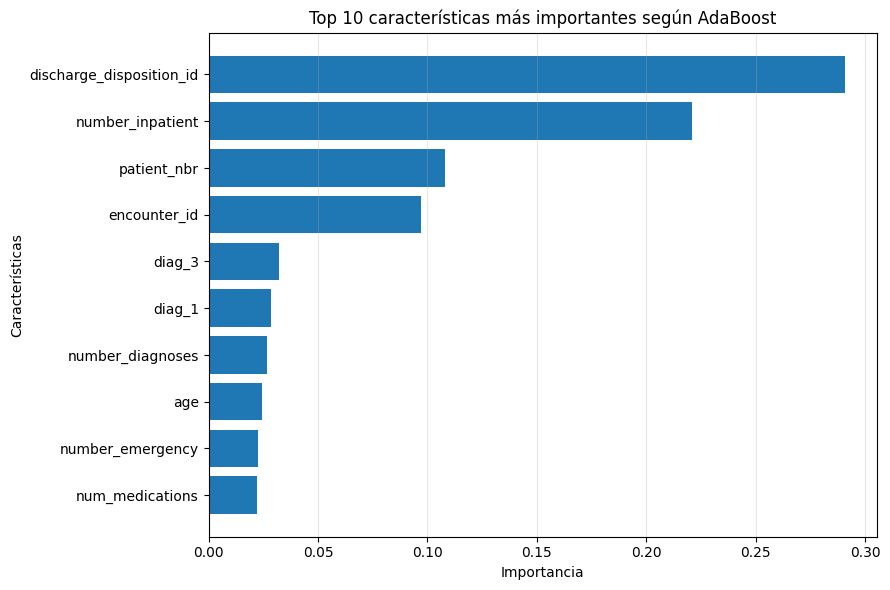

Figura guardada en: ..\visualizacion_gradient_boosting\adaboost_importancia_top10.png


In [18]:
# Visualización de las 10 características más importantes según AdaBoost
carpeta_visualizaciones = Path("../visualizacion_gradient_boosting")
carpeta_visualizaciones.mkdir(exist_ok=True)

top_n = 10
top_features_ada = df_importancia_ada.head(top_n).copy()

plt.figure(figsize=(9, 6))
plt.barh(
    top_features_ada["Feature"][::-1],
    top_features_ada["Importancia (AdaBoost)"][::-1]
)

plt.xlabel("Importancia")
plt.ylabel("Características")
plt.title("Top 10 características más importantes según AdaBoost")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

ruta_figura_ada = carpeta_visualizaciones / "adaboost_importancia_top10.png"
plt.savefig(ruta_figura_ada, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {ruta_figura_ada}")


### 7.2- Importancia de características con XGBoost

Después se repite el mismo proceso con el mejor modelo de **XGBoost**. Se extraen las importancias, se ordenan las variables y se representa el top 10 en una gráfica.

Usar el mismo formato en AdaBoost y XGBoost permite comparar de forma directa si ambos modelos se apoyan en variables similares o si distribuyen la importancia de manera diferente.


In [ ]:
# 1. Obtención de importancias desde el mejor modelo XGBoost
importancias = best_xgb.feature_importances_
feature_names = X.columns.tolist()

# 2. Ordenación de variables por importancia
indices = np.argsort(importancias)[::-1]

ranking_data = []
for i, idx in enumerate(indices, start=1):
    ranking_data.append({
        "Ranking": i,
        "Feature": feature_names[idx],
        "Importancia (XGBoost)": round(importancias[idx], 4)
    })

df_importancia_xgb = pd.DataFrame(ranking_data)
display(df_importancia_xgb)

,Ranking,Feature,Importancia (XGBoost)
0,1,number_inpatient,0.1807
1,2,discharge_disposition_id,0.0696
2,3,number_emergency,0.0423
3,4,diabetesMed,0.0379
4,5,encounter_id,0.0367
5,6,patient_nbr,0.0344
6,7,admission_source_id,0.0335
7,8,number_outpatient,0.0312
8,9,number_diagnoses,0.0301
9,10,age,0.0254


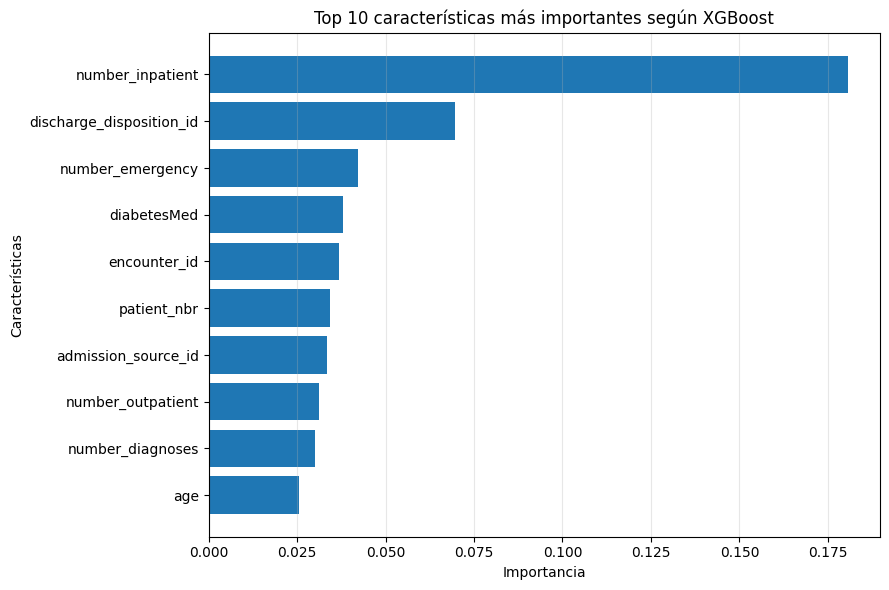

Figura guardada en: ..\visualizacion_gradient_boosting\xgboost_importancia_top10.png


In [14]:
# Visualización de las 10 características más importantes según XGBoost
carpeta_visualizaciones = Path("../visualizacion_gradient_boosting")
carpeta_visualizaciones.mkdir(exist_ok=True)

top_n = 10
top_features = df_importancia_xgb.head(top_n).copy()

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importancia (XGBoost)"][::-1]
)

plt.xlabel("Importancia")
plt.ylabel("Características")
plt.title("Top 10 características más importantes según XGBoost")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

ruta_figura = carpeta_visualizaciones / "xgboost_importancia_top10.png"
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {ruta_figura}")

El análisis de importancia de características muestra diferencias claras entre **AdaBoost** y **XGBoost**.

En **AdaBoost**, la variable más importante es `discharge_disposition_id`, con una importancia de **0.2907**. La segunda es `number_inpatient`, con **0.2208**. Solo estas dos variables suman **0.5115**, es decir, más de la mitad de la importancia total mostrada por el modelo. Esto indica que AdaBoost concentra gran parte de su decisión en pocas variables.

Después aparecen `patient_nbr` con **0.1080** y `encounter_id` con **0.0972**. Estas dos variables son identificadores, por lo que hay que interpretarlas con cuidado. Que aparezcan con tanta importancia no implica necesariamente una explicación clínica directa, sino que el modelo puede estar captando patrones asociados a identificadores concretos o a cómo está organizado el dataset.

A partir de la quinta posición, las importancias de AdaBoost bajan mucho. `diag_3` tiene **0.0320**, `diag_1` tiene **0.0285**, `number_diagnoses` tiene **0.0267**, `age` tiene **0.0244**, `number_emergency` tiene **0.0226** y `num_medications` tiene **0.0220**. Estas variables sí son más interpretables desde el punto de vista clínico, porque están relacionadas con diagnósticos, edad, historial de urgencias, medicación y complejidad del paciente.

En **XGBoost**, la variable más importante es `number_inpatient`, con **0.1807**. Esta variable también aparece en AdaBoost como la segunda más importante, lo que indica que ambos modelos consideran relevante el historial de ingresos previos. Esto tiene sentido dentro del problema, porque los ingresos anteriores pueden estar relacionados con una mayor probabilidad de volver a ingresar.

La segunda variable más importante en XGBoost es `discharge_disposition_id`, con **0.0696**. También coincide con AdaBoost, aunque en XGBoost su peso relativo es bastante menor. Esto indica que ambos modelos tienen en cuenta la situación del paciente al alta, pero XGBoost reparte más la importancia entre otras variables.

El top 10 de XGBoost incluye `number_emergency` (**0.0423**), `diabetesMed` (**0.0379**), `encounter_id` (**0.0367**), `patient_nbr` (**0.0344**), `admission_source_id` (**0.0335**), `number_outpatient` (**0.0312**), `number_diagnoses` (**0.0301**) y `age` (**0.0254**). Varias de estas variables están relacionadas con historial médico, uso previo del hospital, medicación y características del ingreso, por lo que tienen sentido dentro del problema.

La diferencia principal es que **AdaBoost concentra mucho más la importancia**. En AdaBoost, las 10 primeras variables suman **0.8729**, mientras que en XGBoost las 10 primeras suman **0.5218**. Por tanto, XGBoost reparte más la importancia entre un mayor número de características, mientras que AdaBoost se apoya de forma más marcada en pocas variables.

En ambos modelos aparecen identificadores como `encounter_id` y `patient_nbr` dentro de las variables más importantes. Esto debe mencionarse como una limitación interpretativa, porque no son variables clínicas directas. Aun así, también aparecen variables médicamente más razonables como `number_inpatient`, `discharge_disposition_id`, `number_emergency`, `number_diagnoses`, `age`, `diag_1`, `diag_3` y `num_medications`.

En resumen, las gráficas y tablas de importancia muestran que los dos modelos comparten algunas variables relevantes, pero no las usan de la misma forma. AdaBoost da mucho peso a unas pocas características, mientras que XGBoost distribuye mejor la importancia y combina más variables para construir sus predicciones.


## 8- Evaluación final

Finalmente se comparan todos los modelos entrenados en una única tabla.

La comparación incluye **AdaBoost Base**, **Mejor AdaBoost**, **Gradient Boosting Complementario**, **XGBoost Base** y **Mejor XGBoost**. Para todos ellos se muestran las mismas métricas: `CV F1 Macro`, `CV Std`, `Test Accuracy`, `Precision Macro`, `Recall Macro` y `F1-Score Macro`.

Después se construye una tabla resumen que selecciona automáticamente el mejor modelo según `F1-Score Macro` y según `Test Accuracy`.


In [15]:
# Selección de columnas de evaluación
columnas_deseadas = [
    "CV F1 Macro",
    "CV Std",
    "Test Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1-Score Macro"
]

# Construcción de tabla final
df_final = pd.concat([
    df_ada_base.reindex(columns=columnas_deseadas),
    df_ada_grid.loc[["Mejor AdaBoost"]].reindex(columns=columnas_deseadas),
    df_gb_complementario.reindex(columns=columnas_deseadas),
    df_xgb_base.reindex(columns=columnas_deseadas),
    df_xgb_grid.loc[["Mejor XGBoost"]].reindex(columns=columnas_deseadas)
])

display(df_final)

,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
AdaBoost Base,0.3296,0.0031,0.5599,0.3502,0.3720,0.3287
Mejor AdaBoost,0.4138,0.0052,0.5941,0.5580,0.4294,0.4158
Gradient Boosting Complementario,0.4149,0.0009,0.6010,0.5629,0.4306,0.4142
XGBoost Base,0.4061,0.0026,0.5972,0.5754,0.4240,0.4045
Mejor XGBoost,0.4404,0.0031,0.6088,0.5467,0.4485,0.4392


In [16]:
# Identificación automática del mejor modelo según F1-Score Macro y Accuracy

import pandas as pd
from IPython.display import display

# Columnas finales que se van a comparar
columnas_deseadas = ["Test Accuracy", "Precision Macro", "Recall Macro", "F1-Score Macro"]

# Montaje directo de la tabla final con los resultados ya calculados
df_final = pd.concat([
    df_ada_base[columnas_deseadas],
    df_ada_grid.loc[["Mejor AdaBoost"], columnas_deseadas],
    df_gb_complementario[columnas_deseadas],
    df_xgb_base[columnas_deseadas],
    df_xgb_grid.loc[["Mejor XGBoost"], columnas_deseadas]
])

display(df_final)

# Conversión a numérico para comparar correctamente
df_final_numerico = df_final.copy()

for columna in columnas_deseadas:
    df_final_numerico[columna] = pd.to_numeric(df_final_numerico[columna], errors="coerce")

# Selección automática del mejor modelo
mejor_modelo_f1 = df_final_numerico["F1-Score Macro"].idxmax()
mejor_modelo_accuracy = df_final_numerico["Test Accuracy"].idxmax()

resumen_final = pd.DataFrame([
    {
        "Criterio": "Mejor modelo por F1-Score Macro",
        "Modelo seleccionado": mejor_modelo_f1,
        "Valor": round(df_final_numerico.loc[mejor_modelo_f1, "F1-Score Macro"], 4)
    },
    {
        "Criterio": "Mejor modelo por Accuracy",
        "Modelo seleccionado": mejor_modelo_accuracy,
        "Valor": round(df_final_numerico.loc[mejor_modelo_accuracy, "Test Accuracy"], 4)
    }
])

display(resumen_final)

,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
AdaBoost Base,0.5599,0.3502,0.3720,0.3287
Mejor AdaBoost,0.5941,0.5580,0.4294,0.4158
Gradient Boosting Complementario,0.6010,0.5629,0.4306,0.4142
XGBoost Base,0.5972,0.5754,0.4240,0.4045
Mejor XGBoost,0.6088,0.5467,0.4485,0.4392


,Criterio,Modelo seleccionado,Valor
0,Mejor modelo por F1-Score Macro,Mejor XGBoost,0.4392
1,Mejor modelo por Accuracy,Mejor XGBoost,0.6088


La tabla final permite comparar de forma directa el rendimiento de todos los modelos de boosting evaluados en el notebook.

El peor resultado corresponde a **AdaBoost Base**, con un `F1-Score Macro` de **0.3287** y una accuracy de **0.5599**. Esto confirma que la configuración inicial de AdaBoost era demasiado simple para el problema y que necesitaba ajuste de hiperparámetros.

Después del Grid Search, **Mejor AdaBoost** mejora claramente y alcanza un F1 macro de **0.4158** y una accuracy de **0.5941**. Esta mejora demuestra que el ajuste de hiperparámetros ha sido útil, especialmente porque aumenta también la precisión macro hasta **0.5580** y el recall macro hasta **0.4294**.

El **Gradient Boosting Complementario** obtiene la segunda mejor accuracy entre los modelos intermedios, con **0.6010**, y mantiene un F1 macro de **0.4142**. Aunque su accuracy es superior a la de Mejor AdaBoost, su F1 macro queda ligeramente por debajo. Por eso no sería el mejor modelo si el criterio principal es equilibrar el rendimiento entre clases.

**XGBoost Base** obtiene una accuracy de **0.5972** y la mayor precisión macro de la tabla final, con **0.5754**. Sin embargo, su recall macro es **0.4240** y su F1 macro es **0.4045**, por debajo de Mejor AdaBoost y del Gradient Boosting Complementario. Esto indica que su configuración inicial es precisa, pero no ofrece el mejor equilibrio global.

El mejor resultado global lo obtiene **Mejor XGBoost**. Este modelo alcanza el mayor `CV F1 Macro` (**0.4404**), la mayor accuracy (**0.6088**), el mayor recall macro (**0.4485**) y el mayor `F1-Score Macro` en test (**0.4392**). Además, la tabla resumen confirma que también es el modelo seleccionado automáticamente tanto por `F1-Score Macro` como por accuracy.

La elección de **Mejor XGBoost** como modelo final es coherente con el criterio del proyecto, porque el F1 macro es la métrica más adecuada cuando existen clases desbalanceadas. En este caso, no se selecciona simplemente el modelo con mayor precisión, sino el que consigue el mejor equilibrio entre precisión y recall.

Aun así, el F1 macro final de **0.4392** sigue siendo moderado. Esto significa que, aunque XGBoost es el mejor modelo entre los evaluados en este notebook, el problema continúa siendo difícil y no puede considerarse completamente resuelto solo con este modelo. Para un contexto sanitario, este resultado debería interpretarse con cautela y complementarse con análisis de explicabilidad, tratamiento del desbalanceo y comparación con los modelos de las compañeras.

En conclusión, dentro de este notebook de Gradient Boosting, el mejor candidato es **Mejor XGBoost**, porque es el modelo que obtiene el mejor rendimiento empírico en las métricas principales y especialmente en `F1-Score Macro`, que es el criterio más importante para comparar modelos en este problema.
